In [1]:
import pandas as pd
import numpy as np
import SimpleITK as sitk
import os
from show import myshow, pxshow

In [2]:
ptdata = [
['10123_018SCHEU',	'Patient_1', '2005-07-06'],
['10123_014VANSU',	'Patient_5', '2005-06-10'],
['10123_014HILJA',	'Patient_4', '2005-07-19'],
['10123_014ADADE',	'Patient_6', '2005-07-21'],
['10123_014POWTH',	'Patient_7', '2005-05-24'],
['10123_014KRIMA',	'Patient_8', '2005-07-15'],
['10123_017SULSA',	'Patient_9', '2005-06-27'],
['10123_017NORRU',	'Patient_10', '2005-01-28'],
['10123_017MOONO',	'Patient_11', '2005-05-17'],
['10123_011CANMA',	'Patient_12', '2005-05-20'],
['10123_007BETWI',  'n/a',        '2005-04-08']
]
ptidsdf = pd.DataFrame(ptdata, columns=['CVIB','BID','StudyDate'])

In [3]:
ptidsdf

,CVIB,BID,StudyDate
0,10123_018SCHEU,Patient_1,2005-07-06
1,10123_014VANSU,Patient_5,2005-06-10
2,10123_014HILJA,Patient_4,2005-07-19
3,10123_014ADADE,Patient_6,2005-07-21
4,10123_014POWTH,Patient_7,2005-05-24
5,10123_014KRIMA,Patient_8,2005-07-15
6,10123_017SULSA,Patient_9,2005-06-27
7,10123_017NORRU,Patient_10,2005-01-28
8,10123_017MOONO,Patient_11,2005-05-17
9,10123_011CANMA,Patient_12,2005-05-20


In [4]:
dfindex = 2

In [5]:
keypath = "/mnt/S/JNeylon/Research/VENT/RESEARCH-10123-hd8779/output-hd8779-2024-02-07.csv"
niipath = "/mnt/S/JNeylon/Research/VENT/RESEARCH-10123-hd8779"
ventpath = "/mnt/S/JNeylon/Research/VENT"

In [6]:
keydf = pd.read_csv(keypath)

In [7]:
ptdf = keydf[keydf.patient_id == ptidsdf.iloc[dfindex]['CVIB']]
ptdf.head()

,index,experiment_id,int_id,patient_id,visit_number,study_date,descr_summary,initials,marking_review_id,e_sig_id,abbrv_agg,series_instance_uid,series_sub_id,nifti_mask_path,roi_folder_path,comment
20,20,10123,100050494,10123_014HILJA,1,2005-07-19,CT Full (thin) Chest at RV Supine,AJB,106785730.0,1501838.0,"{""LMjF "",""RMnF "",""RMjF ...",1.2.840.113619.2.55.1.1762927653.1917.11217847...,0,/radraid/mkim3-public/data-request/RESEARCH-10...,/radraid/mkim3-public/data-request/RESEARCH-10...,"{'LUL': 1, 'LLL': 1, 'RUL': 1, 'RML': 1, 'RLL'..."
21,21,10123,100050494,10123_014HILJA,1,2005-07-19,CT Full (thin) Chest at RV Supine,CAD,106785780.0,NaN,"{""LLL "",""LLung2 "",""RLung2 ...",1.2.840.113619.2.55.1.1762927653.1917.11217847...,0,NaN,NaN,"{'LUL': 1, 'LLL': 1, 'RUL': 1, 'RML': 1, 'RLL'..."
22,22,10123,100050494,10123_014HILJA,1,2005-07-19,CT Full (thin) Chest at TLC Supine,AJB,105639188.0,1422243.0,"{""RMjF "",""TraCh "",""AORTA ...",1.2.840.113619.2.55.1.1762927653.1917.11217847...,0,/radraid/mkim3-public/data-request/RESEARCH-10...,/radraid/mkim3-public/data-request/RESEARCH-10...,"{'LUL': 1, 'LLL': 1, 'RUL': 1, 'RML': 1, 'RLL'..."
23,23,10123,100050494,10123_014HILJA,1,2005-07-19,CT Full (thin) Chest at TLC Supine,CAD,104640130.0,NaN,"{""RML "",""RLL "",""LUL ...",1.2.840.113619.2.55.1.1762927653.1917.11217847...,0,NaN,NaN,"{'LUL': 2, 'LLL': 2, 'RUL': 1, 'RML': 2, 'RLL'..."
24,24,10123,100050494,10123_014HILJA,2,2006-03-30,CT Full (thin) Chest at RV Supine,CAD,104879980.0,NaN,"{""LLL "",""AORTA "",""TraCh ...",1.2.840.113619.2.55.1.1762927653.1898.11437284...,0,NaN,NaN,"{'LUL': 2, 'LLL': 2, 'RUL': 1, 'RML': 2, 'RLL'..."


In [8]:
rv_idx = 0 # 1 for 8
print(ptdf.iloc[rv_idx].descr_summary)
tlc_idx = 2 # 4 for 8
print(ptdf.iloc[tlc_idx].descr_summary)

CT Full (thin) Chest at RV Supine
CT Full (thin) Chest at TLC Supine


In [9]:
def get_niifilepath(idx):
	seruid = ptdf.iloc[idx].series_instance_uid
	marking_review_id = int(ptdf.iloc[idx].marking_review_id)
	niifile = os.path.join(niipath, seruid + '-0-' + str(marking_review_id) + '.nii.gz')
	return niifile

In [10]:
# rvniifile = os.path.join(ventpath, "VENT_Registrations", ptidsdf.iloc[dfindex]['CVIB'], "rv-tlc-iso", "rv_full_1mm.nii.gz")
# tlcniifile = os.path.join(ventpath, "VENT_Registrations", ptidsdf.iloc[dfindex]['CVIB'], "rv-tlc-iso", "tlc_full_1mm.nii.gz")
# dvffile = os.path.join(ventpath, "VENT_Registrations", ptidsdf.iloc[dfindex]['CVIB'], "rv-tlc-iso", "corrfieldDVF.nii.gz")

In [11]:
rvniifile = get_niifilepath(rv_idx)
print(rvniifile)
tlcniifile = get_niifilepath(tlc_idx)
print(tlcniifile)

/mnt/S/JNeylon/Research/VENT/RESEARCH-10123-hd8779/1.2.840.113619.2.55.1.1762927653.1917.1121784744.656.6-0-106785730.nii.gz
/mnt/S/JNeylon/Research/VENT/RESEARCH-10123-hd8779/1.2.840.113619.2.55.1.1762927653.1917.1121784744.619.3-0-105639188.nii.gz


In [12]:
def make_isotropic(image, interpolator = sitk.sitkNearestNeighbor, new_size=None, sampling=1):
    '''
    Resample an image to isotropic pixels (using smallest spacing from original) and save to file. Many file formats 
    (jpg, png,...) expect the pixels to be isotropic. By default the function uses a linear interpolator. For
    label images one should use the sitkNearestNeighbor interpolator so as not to introduce non-existant labels.
    '''
    original_spacing = image.GetSpacing()
    # Image is already isotropic, just return a copy.
    if new_size is None and all(spc == sampling for spc in original_spacing):
        return sitk.Image(image)
    # Make image isotropic via resampling.
    original_size = image.GetSize()
    # min_spacing = min(original_spacing)
    # new_spacing = [min_spacing]*image.GetDimension()
    new_spacing = [sampling]*image.GetDimension()
    # new_size = [int(round(osz*ospc/min_spacing)) for osz,ospc in zip(original_size, original_spacing)]
    if new_size is None:
        new_size = [int(round(osz*ospc)/nspc+0.3) for osz,ospc,nspc in zip(original_size, original_spacing, new_spacing)]
        print(new_size)
    else:
        new_spacing = [round((osz*ospc)/float(nsz),1) for osz,ospc,nsz in zip(original_size, original_spacing, new_size)]
        print(new_spacing)
    return sitk.Resample(image, new_size, sitk.Transform(), interpolator,
                         image.GetOrigin(), new_spacing, image.GetDirection(), 0,
                         image.GetPixelID())

In [13]:
rvaniso = sitk.ReadImage(rvniifile)

In [14]:
sampling = 8 # resolution for processing in mm

In [15]:
rvimage = make_isotropic(rvaniso, sampling=sampling)

[45, 45, 36]


In [16]:
print(rvimage.GetSpacing())
print(rvimage.GetSize())

(8.0, 8.0, 8.0)
(45, 45, 36)


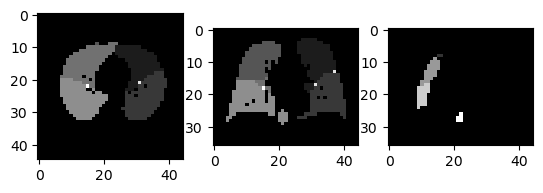

In [17]:
myshow(rvimage)

In [18]:
tlcaniso = sitk.ReadImage(tlcniifile)

In [19]:
tlcimage = make_isotropic(tlcaniso, sampling=sampling)

[45, 45, 39]


In [20]:
print(tlcimage.GetSpacing())
print(tlcimage.GetSize())

(8.0, 8.0, 8.0)
(45, 45, 39)


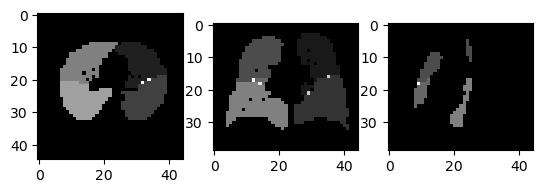

In [21]:
myshow(tlcimage)

In [22]:
labels = {
    1: "LUL",
    2: "LLL",
    3: "RUL",
    4: "RML",
    5: "RLL",
    8: 'LMjF',
	9: 'RMjF',
	10:'RMnF'
}

In [23]:
# rv_left = sitk.GetImageFromArray(np.where(np.isin(sitk.GetArrayFromImage(rvimage).astype(int),[2]), 1, 0))
rv_left = sitk.GetImageFromArray(np.where(np.isin(sitk.GetArrayFromImage(rvimage).astype(int),[1,2,8]), 1, 0))
rv_right = sitk.GetImageFromArray(np.where(np.isin(sitk.GetArrayFromImage(rvimage).astype(int),[3,4,5,9,10]), 1, 0))

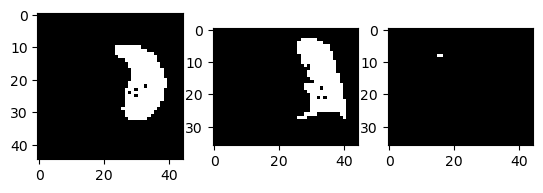

In [24]:
myshow(rv_left)

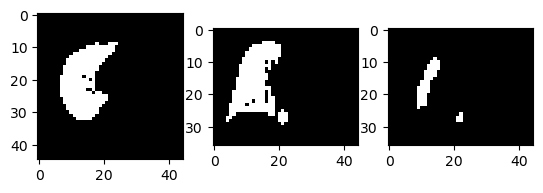

In [25]:
myshow(rv_right)

In [26]:
# dvfdatfile = os.path.join(ventpath, "VENT_Registrations", ptidsdf.iloc[dfindex]['CVIB'], "rv-tlc-iso", "rv_iso_1mm.nii.gz_displacements.dat")
dvffile = os.path.join(ventpath, "VENT_Registrations", ptidsdf.iloc[dfindex]['CVIB'], "rv-tlc-iso", "corrfieldDVF.nii.gz")

In [27]:
dvf = sitk.ReadImage(dvffile)

In [28]:
print(dvf.GetSpacing())
print(dvf.GetSize())

(1.0, 1.0, 1.0, 1.0)
(360, 360, 290, 3)


In [29]:
u_displacements = sitk.GetImageFromArray(sitk.GetArrayFromImage(dvf)[0, ...])
v_displacements = sitk.GetImageFromArray(sitk.GetArrayFromImage(dvf)[1, ...])
w_displacements = sitk.GetImageFromArray(sitk.GetArrayFromImage(dvf)[2, ...])

In [30]:
print(u_displacements.GetSpacing())
print(u_displacements.GetSize())

(1.0, 1.0, 1.0)
(360, 360, 290)


In [31]:
u_resampled = make_isotropic(u_displacements, sampling=sampling)
v_resampled = make_isotropic(v_displacements, sampling=sampling)
w_resampled = make_isotropic(w_displacements, sampling=sampling)

[45, 45, 36]
[45, 45, 36]
[45, 45, 36]


In [32]:
print(u_resampled.GetSpacing())
print(u_resampled.GetSize())

(8.0, 8.0, 8.0)
(45, 45, 36)


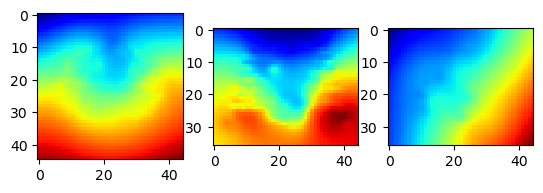

In [33]:
myshow(w_resampled, colormap='jet', colormax=5)

In [34]:
import cudaSetConnect

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [35]:
nprvleft = np.transpose(sitk.GetArrayFromImage(rv_left), axes=(1, 2, 0))

In [36]:
true_indices = np.argwhere(nprvleft)
min_coords = np.min(true_indices, axis=0)
max_coords = np.max(true_indices, axis=0)
margin = 2
min_coords, max_coords

(array([ 9, 22,  2]), array([32, 41, 30]))

In [37]:
cropped_volume = np.array(nprvleft[  min_coords[0]-margin:max_coords[0]+margin,
                            min_coords[1]-margin:max_coords[1]+margin,
                            min_coords[2]-margin:max_coords[2]+margin])

In [38]:
crop_shape = [cropped_volume.shape[0], cropped_volume.shape[1], cropped_volume.shape[2]]
crop_shape

[27, 23, 32]

In [39]:
cropped_volume.flatten().shape

(19872,)

In [40]:
import plotly.express as px
px.imshow(cropped_volume[24,:,:])

In [41]:
connector = cudaSetConnect.SetConnect(cropped_volume.shape, 1, cropped_volume.flatten(order='F'))

CUDA device [b'NVIDIA GeForce RTX 4090'] has 128 Multi-Processors SM 8.9
[0. 0. 0.]  World Origin
(27, 23, 32)  Grid Dimensions
[1. 1. 1.]  Resolution
4684  Total Particles/Vertices


In [42]:
connector.findConnections()

4683
103386  Total Springs


In [43]:
connector.surfParticles

1285

In [44]:
connector.meshifyVolume()

***  17704  Tetrahedrons
***  4006  Surface Triangles
***  3.52  cubic cm Total Volume


In [45]:
connector.vizVolumePoints()

In [46]:
connector.vizSurfaceTriMesh(w_points=False)

In [47]:
connector.vizVolumeTetMesh(w_points=False)

In [48]:
surf_volume = connector.hSurfVolume
s_img = surf_volume.reshape(cropped_volume.shape, order='F')
s_img.shape

(27, 23, 32)

In [62]:
px.imshow(s_img[:,15,:])

In [50]:
up = np.transpose(sitk.GetArrayFromImage(u_resampled), axes=(1, 2, 0))
vp = np.transpose(sitk.GetArrayFromImage(v_resampled), axes=(1, 2, 0))
wp = np.transpose(sitk.GetArrayFromImage(w_resampled), axes=(1, 2, 0))

In [51]:
ucrop = np.array(up[  min_coords[0]-margin:max_coords[0]+margin,
                            min_coords[1]-margin:max_coords[1]+margin,
                            min_coords[2]-margin:max_coords[2]+margin]).flatten(order='F')
vcrop = np.array(vp[  min_coords[0]-margin:max_coords[0]+margin,
                            min_coords[1]-margin:max_coords[1]+margin,
                            min_coords[2]-margin:max_coords[2]+margin]).flatten(order='F')
wcrop = np.array(wp[  min_coords[0]-margin:max_coords[0]+margin,
                            min_coords[1]-margin:max_coords[1]+margin,
                            min_coords[2]-margin:max_coords[2]+margin]).flatten(order='F')

In [52]:
du = ucrop[connector.nzindices]
dv = vcrop[connector.nzindices]
dw = wcrop[connector.nzindices]

In [ ]:
pdvf = np.stack([dw,du,dv], axis=1)
pdvf.shape


(4684, 3)

In [54]:
pdvf.flatten()[0:3]

array([ 0.80879557,  2.78951216, -3.71922421])

In [55]:
# newPos = connector.hPos.reshape(-1,4)

In [56]:
# newPos[:,0:3] += pdvf

In [57]:
import springStiffnessOptimizer

In [58]:
train_iters=2
num_frames=25
train_rate=10.0
stage_path='usd_files/stages/hilja_LLL.usd'

In [59]:
proto = springStiffnessOptimizer.ProtoCage(connector,
                                           stage_path=stage_path,
                                           num_frames=num_frames,
                                           train_iters=train_iters,
                                           train_rate=train_rate,
                                           dvf=pdvf)

Warp 1.7.2 initialized:
   CUDA Toolkit 12.8, Driver 12.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4090" (24 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/jacko/.cache/warp/1.7.2
2501


In [60]:
loss = 99999

for iteration in range(train_iters):
# iteration = 0
# while loss > 0.005:
    proto.step()
    loss = proto.loss.numpy()
    print(f"[{iteration:3d}] loss={loss.mean():.8f}")

    if proto.renderer and (iteration == (train_iters-1)):
    # (iteration == train_iters - 1 or iteration % proto.render_iteration_steps == 0):
        proto.render()

    iteration += 1

if proto.renderer:
    proto.renderer.save()

    Module springStiffnessOptimizer b535e6b load on device 'cuda:0' took 0.56 ms  (cached)
    Module warp.sim.integrator_euler 604c2a7 load on device 'cuda:0' took 0.42 ms  (cached)
    Module warp.sim.particles fe53145 load on device 'cuda:0' took 0.12 ms  (cached)
    Module warp.sim.integrator 3b115ab load on device 'cuda:0' took 0.23 ms  (cached)
Spring stiffness: [10.0122595 10.060919   9.96827   ... 10.        10.        10.       ]
step took 713.88 ms
[  0] loss=4.71841574
Spring stiffness: [10.024513 10.12177   9.936554 ... 10.       10.       10.      ]
step took 584.99 ms
[  1] loss=9.43682671
render took 26725.69 ms
Saved the USD stage file at `/home/jacko/Code/warpbiomechanics/usd_files/stages/hilja_LLL.usd`


In [64]:
avg_stiffness = proto.get_average_stiffness_per_particles()

# Map average stiffness to 3D volume
stiffness_map = np.zeros_like(connector.index_volume, dtype=np.float32)
for i, idx in enumerate(connector.nzindices):
    stiffness_map[idx] = avg_stiffness[i]

In [65]:
k_img = stiffness_map.reshape(s_img.shape[2],s_img.shape[1],s_img.shape[0]).T
#temp = i_img.T.reshape(-1)
#print(np.array_equal(iso_volume,temp))
px.imshow(k_img[:,int(0.5*k_img.shape[1]),:])

In [ ]:
# from utils.display import display_usd

In [ ]:
# usd_path = "usd_files/"
# stage_path = usd_path + "stages/"

In [ ]:
# from pxr import Gf, Usd, UsdGeom, Sdf

# def trimesh_to_usd(vertices, triangles, name, path):
# 	roi_usd_path = path + name + '.usda'
# 	print(roi_usd_path)
# 	if os.path.isfile(roi_usd_path):
# 		stage = Usd.Stage.Open(roi_usd_path)
# 	else:
# 		stage = Usd.Stage.CreateNew(roi_usd_path)
# 	root_xform = UsdGeom.Xform.Define(stage, '/Root')
# 	mesh_path = Sdf.Path(root_xform.GetPath()).AppendChild('primitive')
# 	mesh = UsdGeom.Mesh.Define(stage, mesh_path)
# 	mesh.GetPointsAttr().Set(np.asarray(vertices))
# 	mesh.CreateFaceVertexIndicesAttr(np.asarray(triangles))
# 	# mesh.CreateOrientationAttr().Set(UsdGeom.Tokens.leftHanded)
# 	# mesh.CreateSubdivisionSchemeAttr().Set("none")
# 	stage.GetRootLayer().Save()

# def tetmesh_to_usd(vertices, tet_indices, name, path):
# 	roi_usd_path = path + name + '.usda'
# 	print(roi_usd_path)
# 	if os.path.isfile(roi_usd_path):
# 		stage = Usd.Stage.Open(roi_usd_path)
# 	else:
# 		stage = Usd.Stage.CreateNew(roi_usd_path)
# 	root_xform = UsdGeom.Xform.Define(stage, '/Root')
# 	mesh_path = Sdf.Path(root_xform.GetPath()).AppendChild('primitive')
# 	# tet_mesh_prim = UsdGeom.TetMesh.Define(stage, "/TetrahedralMesh")
# 	# tet_mesh_prim = Sdf.Path(root_xform.GetPath()).AppendChild('primitive')
# 	tet_mesh_prim = UsdGeom.TetMesh.Define(stage, mesh_path)
# 	tet_mesh_prim.GetPointsAttr().Set(vertices)
# 	tet_mesh_prim.GetTetVertexIndicesAttr().Set(tet_indices)
# 	stage.GetRootLayer().Save()

In [ ]:
# name = 'hilja_leftlung'

In [ ]:
# trimesh_to_usd(connector.getVolumePoints(), connector.triangles, name + '_trimesh', stage_path)

In [ ]:
# tetmesh_to_usd(connector.getVolumePoints(), connector.tetras, name + '_tetmesh', stage_path)

In [ ]:
# def load_usd_mesh(usd_path, mesh_name):
#     stage = Usd.Stage.Open(usd_path + mesh_name + '.usda')
#     mesh = UsdGeom.Mesh(stage.GetPrimAtPath('/Root/primitive'))
#     points = mesh.GetPointsAttr().Get()
#     faces = mesh.GetFaceVertexIndicesAttr().Get()
#     return points, faces

In [ ]:
# points, faces = load_usd_mesh(usd_path + "rois/", name)

In [ ]:
# import math
# import warp as wp
# import warp.render
# import warp.sim
# import warp.sim.render

In [ ]:
# @wp.kernel
# def deform(positions: wp.array(dtype=wp.vec3), t: float):
#     tid = wp.tid()

#     x = positions[tid]

#     offset = -wp.sin(x[0]) * 0.5
#     scale = wp.sin(t)

#     x = x + wp.vec3(0.0, offset * scale, 0.0)

#     positions[tid] = x

In [ ]:
# @wp.kernel
# def simulate(
#     positions: wp.array(dtype=wp.vec3),
#     velocities: wp.array(dtype=wp.vec3),
#     mesh: wp.uint64,
#     margin: float,
#     dt: float,
# ):
#     tid = wp.tid()

#     x = positions[tid]
#     v = velocities[tid]

#     v = v + wp.vec3(0.0 + 9.8, 0.0, 0.0 + 9.8) * dt - v * 0.1 * dt
#     xpred = x + v * dt

#     max_dist = 1.5

#     query = wp.mesh_query_point_sign_normal(mesh, xpred, max_dist)
#     if query.result:
#         p = wp.mesh_eval_position(mesh, query.face, query.u, query.v)

#         delta = xpred - p

#         dist = wp.length(delta) * query.sign
#         err = dist - margin

#         # mesh collision
#         if err < 0.0:
#             n = wp.normalize(delta) * query.sign
#             xpred = xpred - n * err

#     # pbd update
#     v = (xpred - x) * (1.0 / dt)
#     x = xpred

#     positions[tid] = x
#     velocities[tid] = v

In [ ]:
# class TwistSoftBody:
#     def __init__(self, usd_path="/home/jacko/Code/dynamo/usd_files/rois", model_name="Eye_L", num_frames=300):
#         rng = np.random.default_rng(42)
#         self.stage_path = usd_path + model_name + '-render.usda' 
#         self.model_path = usd_path + model_name + '.usda'
        
#         self.num_particles = 1000
#         self.num_frames = num_frames
#         fps = 60
#         sim_duration = self.num_frames / fps
        
#         self.sim_dt = 1.0 / fps
#         self.sim_time = 0.0
#         self.sim_timers = {}
#         self.sim_margin = 0.1

#         usd_stage = Usd.Stage.Open(self.model_path)
#         usd_geom = UsdGeom.Mesh(usd_stage.GetPrimAtPath('/Root/primitive'))
#         usd_scale = 1.0

#         self.mesh = wp.Mesh(
#             points=wp.array(usd_geom.GetPointsAttr().Get() * usd_scale, dtype=wp.vec3),
#             indices=wp.array(usd_geom.GetFaceVertexIndicesAttr().Get(), dtype=int),
#         )

#         # random particles
#         init_pos = (rng.random((self.num_particles, 3)) - np.array([0.5, -1.5, 0.5])) * 50.0
#         init_vel = rng.random((self.num_particles, 3)) * 0.0

#         self.positions = wp.from_numpy(init_pos, dtype=wp.vec3)
#         self.velocities = wp.from_numpy(init_vel, dtype=wp.vec3)

#         if self.stage_path:
#             self.renderer = wp.render.UsdRenderer(self.stage_path)
#         else:
#             self.renderer = None

#     def deform_step(self):
#         with wp.ScopedTimer("step", dict=self.sim_timers):
#             wp.launch(kernel=deform, dim=len(self.mesh.points), inputs=[self.mesh.points, self.sim_time])

#             # refit the mesh BVH to account for the deformation
#             self.mesh.refit()

#             wp.launch(
#                 kernel=simulate,
#                 dim=self.num_particles,
#                 inputs=[self.positions, self.velocities, self.mesh.id, self.sim_margin, self.sim_dt],
#             )

#             self.sim_time += self.sim_dt

#     def render(self):
#         if self.renderer is None:
#             return

#         with wp.ScopedTimer("render"):
#             self.renderer.begin_frame(self.sim_time)
#             self.renderer.render_mesh(
#                 name="mesh",
#                 points=self.mesh.points.numpy(),
#                 indices=self.mesh.indices.numpy(),
#                 colors=(0.35, 0.55, 0.9),
#             )
#             self.renderer.render_points(
#                 name="points", points=self.positions.numpy(), radius=self.sim_margin, colors=(0.8, 0.3, 0.2)
#             )
#             self.renderer.end_frame()

In [ ]:
# twister = TwistSoftBody(usd_path=usd_path + "rois/", model_name=name, num_frames=500)

In [ ]:
# for _ in range(500):
#     twister.deform_step()
#     twister.render()

In [ ]:
# if twister.renderer:
#     twister.renderer.save()

In [ ]:
# import math

# import warp as wp
# import warp.sim
# import warp.sim.render


# @wp.kernel
# def twist_points(
#     rest: wp.array(dtype=wp.vec3), points: wp.array(dtype=wp.vec3), mass: wp.array(dtype=float), xform: wp.transform
# ):
#     tid = wp.tid()

#     r = rest[tid]
#     p = points[tid]
#     m = mass[tid]

#     # twist the top layer of particles in the beam
#     if m == 0 and p[1] != 0.0:
#         points[tid] = wp.transform_point(xform, r)


# @wp.kernel
# def compute_volume(points: wp.array(dtype=wp.vec3), indices: wp.array2d(dtype=int), volume: wp.array(dtype=float)):
#     tid = wp.tid()

#     i = indices[tid, 0]
#     j = indices[tid, 1]
#     k = indices[tid, 2]
#     l = indices[tid, 3]

#     x0 = points[i]
#     x1 = points[j]
#     x2 = points[k]
#     x3 = points[l]

#     x10 = x1 - x0
#     x20 = x2 - x0
#     x30 = x3 - x0

#     v = wp.dot(x10, wp.cross(x20, x30)) / 6.0

#     wp.atomic_add(volume, 0, v)


# class Example:
#     def __init__(self, points, tet_indices, stage_path=None, num_frames=300):
#         self.sim_substeps = 64
#         self.num_frames = num_frames
#         fps = 60
#         sim_duration = self.num_frames / fps
#         self.frame_dt = 1.0 / fps
#         self.sim_dt = self.frame_dt / self.sim_substeps
#         self.sim_time = 0.0
#         self.lift_speed = 2.5 / sim_duration * 2.0  # from Smith et al.
#         self.rot_speed = math.pi / sim_duration
#         self.points = points
#         self.tet_indices = tet_indices.flatten()

#         builder = wp.sim.ModelBuilder()

#         # cell_dim = 15
#         # cell_size = 2.0 / cell_dim
#         # center = cell_size * cell_dim * 0.5
#         # # bear
#         # asset_stage = Usd.Stage.Open(os.path.join(warp.examples.get_asset_directory(), "bear.usd"))
#         # geom = UsdGeom.Mesh(asset_stage.GetPrimAtPath("/root/bear"))
#         # points = geom.GetPointsAttr().Get()
#         # xform = Gf.Matrix4f(geom.ComputeLocalToWorldTransform(0.0))
#         # for i in range(len(points)):
#         #     points[i] = xform.Transform(points[i])
#         # self.points = [wp.vec3(point) for point in points]
#         # self.tet_indices = geom.GetPrim().GetAttribute("tetraIndices").Get()

#         builder.add_soft_mesh(
#             pos=wp.vec3(0.0, 0.5, 0.0),
#             rot=wp.quat_identity(),
#             scale=1.0,
#             vel=wp.vec3(0.0, 0.0, 0.0),
#             vertices=self.points,
#             indices=self.tet_indices,
#             density=1.0,
#             k_mu=2000.0,
#             k_lambda=2000.0,
#             k_damp=2.0,
#             tri_ke=0.0,
#             tri_ka=1e-8,
#             tri_kd=0.0,
#             tri_drag=0.0,
#             tri_lift=0.0,
#         )

#         self.model = builder.finalize()
#         self.model.ground = False
#         self.model.gravity[1] = 0.0

#         self.integrator = wp.sim.SemiImplicitIntegrator()

#         self.rest = self.model.state()
#         # self.rest_vol = (cell_size * cell_dim) ** 3

#         self.state_0 = self.model.state()
#         self.state_1 = self.model.state()

#         self.volume = wp.zeros(1, dtype=wp.float32)

#         if stage_path:
#             self.renderer = wp.sim.render.SimRenderer(self.model, stage_path, scaling=20.0)
#         else:
#             self.renderer = None

#         self.use_cuda_graph = wp.get_device().is_cuda
#         if self.use_cuda_graph:
#             with wp.ScopedCapture() as capture:
#                 self.simulate()
#             self.graph = capture.graph

#     def simulate(self):
#         for _ in range(self.sim_substeps):
#             self.state_0.clear_forces()
#             self.state_1.clear_forces()

#             self.integrator.simulate(self.model, self.state_0, self.state_1, self.sim_dt)

#             # swap states
#             (self.state_0, self.state_1) = (self.state_1, self.state_0)

#     def step(self):
#         with wp.ScopedTimer("step"):
#             xform = wp.transform(
#                 (0.0, self.lift_speed * self.sim_time, 0.0),
#                 wp.quat_from_axis_angle(wp.vec3(0.0, 1.0, 0.0), self.rot_speed * self.sim_time),
#             )
#             wp.launch(
#                 kernel=twist_points,
#                 dim=len(self.state_0.particle_q),
#                 inputs=[self.rest.particle_q, self.state_0.particle_q, self.model.particle_mass, xform],
#             )
#             if self.use_cuda_graph:
#                 wp.capture_launch(self.graph)
#             else:
#                 self.simulate()
#             self.volume.zero_()
#             wp.launch(
#                 kernel=compute_volume,
#                 dim=self.model.tet_count,
#                 inputs=[self.state_0.particle_q, self.model.tet_indices, self.volume],
#             )
#         self.sim_time += self.frame_dt

#     def render(self):
#         if self.renderer is None:
#             return

#         with wp.ScopedTimer("render"):
#             self.renderer.begin_frame(self.sim_time)
#             self.renderer.render(self.state_0)
#             self.renderer.end_frame()

In [ ]:
# num_frames = 50
# usd_path = "usd_files/"
# name = 'hilja_leftlung'
# stage_path = usd_path + "rois/" + name + '_tetmesh' + '.usda'

In [ ]:
# example = Example(points=connector.getVolumePoints(), tet_indices=connector.tetras, stage_path=stage_path, num_frames=num_frames)

# for _ in range(num_frames):
#     example.step()
#     example.render()

# if example.renderer:
#     example.renderer.save()